# S4c. Window size inside the ECM arm — 96 vs 128 vs 192 µm

`ecm_fov192` was added to test one specific idea from S4: that the ECM channel earns its
+43% at 96 µm by supplying **large-scale spatial context a small window lacks**. If that
is what is happening, a larger window should need matrix less, and the FOV optimum should
not move upward just because the channel was added. This notebook checks where the optimum
actually sits now.

All three ECM runs are read at **epoch 199**, all trained identically (200 epochs, warm
up/down 20/20, weight decay 0, batch 128, 1024 crops per tissue, `pixel_size` 2.0, the same
8 ROIs). The two final-sweep runs are read at the same epoch as a no-ECM reference — they
exist only at 96 and 128 µm, so the channel comparison covers two of the three FOVs.

### Raw kappa cannot be compared across FOV. Gain can.

S4 compared two models at the **same** FOV, so the candidate window positions were
identical and raw kappa was directly comparable on a shared grid. That does not extend
here: 96, 128 and 192 µm tile the same tissue into ~1050, ~640 and ~330 windows of
different physical size. Bigger windows overlap more tissue context and are more similar to
their neighbours **by construction**, so kappa rises with FOV whether or not the model got
better.

The gain metric is built for exactly this. Each config is scored against a composition
baseline clustered on **its own** windows, so the geometry term appears in numerator and
denominator and cancels. Section 4 shows the two side by side; they rank the FOVs
differently, and the raw one is the misleading one.

### The baseline is the ten cell channels, renormalised

ECM is dropped from the baseline. Three reasons: it is then the same quantity at every
FOV; "what you could have got by counting cell types in these windows" is the comparison
worth beating; and leaving matrix in would let the baseline absorb the very signal the
screen is about. Composition comes from the raster rather than the model, so dropping
channel 10 and renormalising should reproduce the 10-channel run's own baseline exactly —
asserted in section 2, not assumed.

### Two filters, because a flat cell count is not a flat density

A 192 µm window has 4× the area of a 96 µm one, so `n_cells >= 10` admits a far emptier
window at 192. Everything is therefore computed twice:

| filter | threshold at 96 / 128 / 192 µm | meaning |
|---|---|---|
| `flat` | 10 / 10 / 10 | S4's operating point; reproduces its numbers exactly |
| `scaled` | 10 / 18 / 40 | constant minimum *density*, `10 × (fov/96)²` |

A FOV ranking that flips between them is a filter artefact rather than a result.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import importlib
import imc_tm
importlib.reload(imc_tm)   # sys.modules caches; a warm kernel keeps stale code

import gc
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

pd.set_option("display.width", 240)
EPOCH = 199
RESOLUTIONS = (0.6, 0.8, 1.0, 1.25, 1.5)
N_CELL_CH = len(imc_tm.CELL_TYPES)
RESULTS = imc_tm.RESULTS_DIR      # result tables sit beside the code, as in prep_imc_spatial/

print(imc_tm.compat_summary())
print()
print(imc_tm.ecm_status())

tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt

            fov_um  last_epoch  last_loss  periodic_ckpts  latest_ckpt_epoch
name                                                                        
ecm_fov96       96         199      1.100               8                199
ecm_fov128     128         199      0.634               8                199
ecm_fov192     192         199      0.244               8                199


## 1. Featurise every arm on a permissive grid

`n_element_min_for_crop = 1` at featurisation, so nothing is culled here and the filters
below are the only thing selecting windows — applied identically to every arm.

In [2]:
JOBS = []
for spec in imc_tm.ECM_SWEEP:
    JOBS.append(dict(tag=spec["name"], arm="ecm", fov=spec["fov_um"],
                     cfg=imc_tm.ecm_config_dict(spec),
                     ckpt=imc_tm.ecm_checkpoint(spec["name"], EPOCH),
                     h5ad=imc_tm.ecm_h5ad_dir(spec["name"])))
for spec in imc_tm.FINAL_SWEEP:      # no-ECM reference; exists only at 96 and 128
    JOBS.append(dict(tag=spec["name"], arm="base", fov=spec["fov_um"],
                     cfg=imc_tm.final_config_dict(spec),
                     ckpt=imc_tm.final_checkpoint(spec["name"], EPOCH),
                     h5ad=imc_tm.final_h5ad_dir(spec["name"])))

R = {}
for j in JOBS:
    adatas = imc_tm.load_all_anndata(j["h5ad"])
    dm = imc_tm.make_datamodule(j["cfg"], n_element_min_for_crop=1)
    model = imc_tm.load_model(j["ckpt"])
    r = imc_tm.featurize_windows(model, dm, adatas, frac_overlap=0.0, seed=0, verbose=False)
    r.update(j); R[j["tag"]] = r
    print("  {:<13s} {:<5s} fov {:>3d}  {:5d} windows  composition {}".format(
        j["tag"], j["arm"], j["fov"], len(r["roi"]), r["composition"].shape))
    del model, dm, adatas; gc.collect(); torch.cuda.empty_cache()

[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:92: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/sta

number of elements ---> 5132
mean and median spacing 9.040660615080185, 7.006655558763179
The dense shape of the image is -> torch.Size([11, 530, 530])


number of elements ---> 11945
mean and median spacing 5.726177635707582, 5.503164345211142
The dense shape of the image is -> torch.Size([11, 580, 580])


number of elements ---> 11050
mean and median spacing 5.941896094265878, 5.842315227480571
The dense shape of the image is -> torch.Size([11, 581, 581])


...

number of elements ---> 7572
mean and median spacing 6.975763445255431, 6.472262341392154
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 8724
mean and median spacing 6.807801972872951, 6.434931372051974
The dense shape of the image is -> torch.Size([10, 580, 581])


number of elements ---> 8250
mean and median spacing 6.682641894353679, 6.308046216872109
The dense shape of the image is -> torch.Size([10, 530, 531])


number of elements ---> 10597
mean and median spacing 5.94761912150776, 5.836300547191762
The dense shape of the image is -> torch.Size([10, 530, 532])


  final_fov128  base  fov 128    700 windows  composition (700, 10)


## 2. The baseline really is the 10-channel run's own composition

Composition is read off the raster, not produced by the model, so the ten cell channels of
an 11-channel run — renormalised — must equal what the 10-channel run computes on the same
windows. If this is not 0, the arms are not being scored against a common reference and
nothing below means anything.

In [3]:
def cell_comp(r):
    c = np.asarray(r["composition"])[:, :N_CELL_CH]
    return c / np.clip(c.sum(1, keepdims=True), 1e-9, None)

for fov in (96, 128):
    e, b = R["ecm_fov%d" % fov], R["final_fov%d" % fov]
    idx = imc_tm.align_to_grid(b, e)                 # raises if the grids disagree
    d = np.abs(cell_comp(e)[idx] - cell_comp(b)).max()
    print("fov{:3d}: max |ECM run's cell composition - 10-channel run's own| = {:.6f}".format(fov, d))
    assert d < 1e-6, "baselines differ -- the arms are not comparable"
print("\nPASS -- all arms share one baseline definition")

fov 96: max |ECM run's cell composition - 10-channel run's own| = 0.000000
fov128: max |ECM run's cell composition - 10-channel run's own| = 0.000000

PASS -- all arms share one baseline definition


## 3. Score every arm under both filters

In [4]:
def evaluate(X, centers, roi):
    g = imc_tm.umap_graph(X)                          # PCA+UMAP once, Leiden per setting
    return {res: dict(kappa=imc_tm.spatial_coherence(
                          centers, roi, imc_tm.leiden_on(g["graph"], resolution=res, seed=0),
                          k=4, n_perm=200, seed=0)["kappa"],
                      n_clusters=len(np.unique(imc_tm.leiden_on(g["graph"], resolution=res, seed=0))))
            for res in RESOLUTIONS}

rows = []
for name, r in R.items():
    for fname, thr in (("flat", 10.0), ("scaled", 10.0 * (r["fov"] / 96.0) ** 2)):
        keep = r["n_cells"] >= thr
        cen, roi = r["centers_um"][keep], r["roi"][keep]
        dino = evaluate(r["features"][keep], cen, roi)
        comp = evaluate(cell_comp(r)[keep], cen, roi)
        gains = {res: imc_tm.safe_gain(dino[res]["kappa"], comp[1.0]["kappa"]) for res in RESOLUTIONS}
        rows.append(dict(config=name, arm=r["arm"], fov=r["fov"], filt=fname,
                         threshold=int(round(thr)), n_windows=int(keep.sum()),
                         n_clusters=dino[1.0]["n_clusters"],
                         kappa=dino[1.0]["kappa"], kappa_comp=comp[1.0]["kappa"],
                         gain=gains[1.0], gain_lo=min(gains.values()), gain_hi=max(gains.values())))
        print("  {:<13s} {:<6s} thr {:>3d}  n={:4d}  kappa {:.4f}  gain {:.3f} [{:.3f}, {:.3f}]".format(
            name, fname, rows[-1]["threshold"], rows[-1]["n_windows"],
            rows[-1]["kappa"], rows[-1]["gain"], rows[-1]["gain_lo"], rows[-1]["gain_hi"]))
T = pd.DataFrame(rows)
T.to_csv(RESULTS / "ecm_fov_three_way.csv", index=False)

  ecm_fov96     flat   thr  10  n=1053  kappa 0.2860  gain 1.805 [1.593, 2.041]


  ecm_fov96     scaled thr  10  n=1053  kappa 0.2860  gain 1.805 [1.593, 2.041]


  ecm_fov128    flat   thr  10  n= 637  kappa 0.3795  gain 2.563 [2.482, 3.011]


  ecm_fov128    scaled thr  18  n= 595  kappa 0.3916  gain 2.480 [2.409, 2.753]


  ecm_fov192    flat   thr  10  n= 325  kappa 0.4431  gain 2.068 [1.883, 2.086]


  ecm_fov192    scaled thr  40  n= 286  kappa 0.4477  gain 2.169 [2.014, 2.347]


  final_fov96   flat   thr  10  n=1053  kappa 0.2004  gain 1.265 [1.237, 1.663]


  final_fov96   scaled thr  10  n=1053  kappa 0.2004  gain 1.265 [1.237, 1.663]


  final_fov128  flat   thr  10  n= 637  kappa 0.3507  gain 2.369 [2.305, 2.582]


  final_fov128  scaled thr  18  n= 595  kappa 0.3514  gain 2.226 [2.165, 2.423]


In [5]:
for f in ("flat", "scaled"):
    print("=== filter: {} ===".format(f))
    print(T.query("filt == @f").sort_values(["arm", "fov"])[
        ["config","arm","fov","threshold","n_windows","n_clusters",
         "kappa","kappa_comp","gain","gain_lo","gain_hi"]].round(4).to_string(index=False))
    print()

=== filter: flat ===
      config  arm  fov  threshold  n_windows  n_clusters  kappa  kappa_comp   gain  gain_lo  gain_hi
 final_fov96 base   96         10       1053          15 0.2004      0.1584 1.2652   1.2367   1.6629
final_fov128 base  128         10        637          15 0.3507      0.1480 2.3691   2.3052   2.5815
   ecm_fov96  ecm   96         10       1053          15 0.2860      0.1584 1.8054   1.5926   2.0410
  ecm_fov128  ecm  128         10        637          14 0.3795      0.1480 2.5634   2.4819   3.0113
  ecm_fov192  ecm  192         10        325          11 0.4431      0.2142 2.0683   1.8834   2.0863

=== filter: scaled ===
      config  arm  fov  threshold  n_windows  n_clusters  kappa  kappa_comp   gain  gain_lo  gain_hi
 final_fov96 base   96         10       1053          15 0.2004      0.1584 1.2652   1.2367   1.6629
final_fov128 base  128         18        595          15 0.3514      0.1579 2.2259   2.1653   2.4228
   ecm_fov96  ecm   96         10       1053  

## 4. Why raw kappa would have given the wrong answer

Left: raw coherence. Right: the same runs as gain over their own composition baseline.
The 192 µm model has the **highest raw kappa of any config here** — and the second-best
gain, because its baseline rose just as much. Bigger windows make neighbours more alike for
both the model and a cell-count vector; only the ratio says whether the model did anything
a cell count could not.

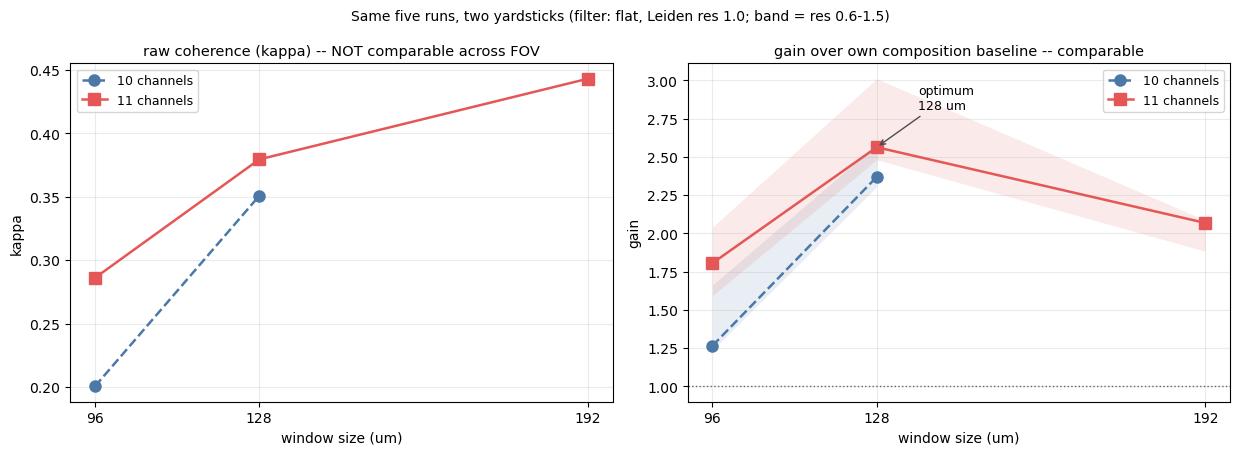

In [6]:
ARM_C = {"base": "#4C78A8", "ecm": "#E45756"}
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, col, ttl in ((axes[0], "kappa", "raw coherence (kappa) -- NOT comparable across FOV"),
                     (axes[1], "gain", "gain over own composition baseline -- comparable")):
    for arm, style in (("base", dict(ls="--", marker="o")), ("ecm", dict(ls="-", marker="s"))):
        sub = T.query("filt == 'flat' and arm == @arm").sort_values("fov")
        if not len(sub):
            continue
        ax.plot(sub.fov, sub[col], color=ARM_C[arm], lw=1.8, ms=8,
                label="{} channels".format(10 if arm == "base" else 11), **style)
        if col == "gain":
            ax.fill_between(sub.fov, sub.gain_lo, sub.gain_hi, color=ARM_C[arm], alpha=0.12, lw=0)
    ax.set_xticks([96, 128, 192]); ax.set_xlabel("window size (um)")
    ax.set_title(ttl, fontsize=10.5); ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
axes[0].set_ylabel("kappa"); axes[1].set_ylabel("gain")
axes[1].axhline(1.0, color="0.4", lw=1, ls=":")
# mark the optimum on the comparable panel only
best = T.query("filt == 'flat' and arm == 'ecm'").sort_values("gain").iloc[-1]
axes[1].annotate("optimum\n{} um".format(int(best.fov)), xy=(best.fov, best.gain),
                 xytext=(best.fov + 8, best.gain + 0.25), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="0.3"))
fig.suptitle("Same five runs, two yardsticks (filter: flat, Leiden res 1.0; band = res 0.6-1.5)",
             fontsize=10)
plt.tight_layout(); plt.show()

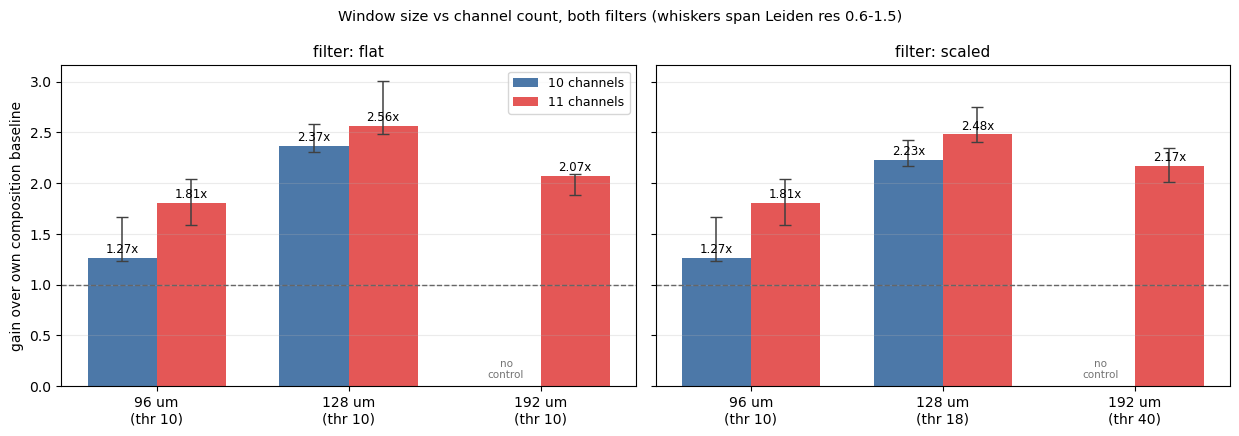

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), sharey=True)
for ax, f in zip(axes, ("flat", "scaled")):
    sub = T.query("filt == @f")
    fovs = sorted(sub.fov.unique())
    width = 0.36
    for i, arm in enumerate(("base", "ecm")):
        s = sub.query("arm == @arm").set_index("fov").reindex(fovs)
        xs = np.arange(len(fovs)) + (i - 0.5) * width
        ax.bar(xs, s["gain"].fillna(0), width=width, color=ARM_C[arm],
               label="{} channels".format(10 if arm == "base" else 11))
        lo = (s["gain"] - s["gain_lo"]).clip(lower=0)
        hi = (s["gain_hi"] - s["gain"]).clip(lower=0)
        ok = s["gain"].notna()
        ax.errorbar(xs[ok.values], s["gain"][ok], yerr=np.vstack([lo[ok], hi[ok]]),
                    fmt="none", ecolor="0.25", capsize=4, lw=1.1)
        for x, v, n in zip(xs, s["gain"], s["n_windows"]):
            if np.isfinite(v):
                ax.text(x, v + 0.05, "{:.2f}x".format(v), ha="center", fontsize=8.5)
            else:
                ax.text(x, 0.08, "no\ncontrol", ha="center", fontsize=7.5, color="0.45")
    ax.set_xticks(np.arange(len(fovs)))
    ax.set_xticklabels(["{} um\n(thr {})".format(v, int(sub.query("fov == @v").threshold.iloc[0]))
                        for v in fovs])
    ax.axhline(1.0, color="0.4", lw=1, ls="--")
    ax.set_title("filter: {}".format(f), fontsize=11); ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("gain over own composition baseline"); axes[0].legend(fontsize=9)
fig.suptitle("Window size vs channel count, both filters (whiskers span Leiden res 0.6-1.5)",
             fontsize=10.5)
plt.tight_layout(); plt.show()

## 5. What the ECM channel is worth, by window size

Only 96 and 128 µm have a no-ECM counterpart, so this is the whole of what can be said
about the channel from matched runs. The trend is the point.

In [8]:
d = []
for f in ("flat", "scaled"):
    for fov in (96, 128, 192):
        s = T.query("filt == @f and fov == @fov")
        b = s.query("arm == 'base'")["gain"]
        e = s.query("arm == 'ecm'")["gain"]
        d.append(dict(filt=f, fov=fov,
                      base=float(b.iloc[0]) if len(b) else np.nan,
                      ecm=float(e.iloc[0]) if len(e) else np.nan,
                      uplift=(float(e.iloc[0]) / float(b.iloc[0])) if len(b) and len(e) else np.nan))
D = pd.DataFrame(d)
D["uplift_pct"] = (D["uplift"] - 1) * 100
display(D.round(3))
print("ECM uplift shrinks as the window grows -- consistent with the channel supplying")
print("large-scale context that a small window lacks and a large one already has.")
print("192 um has no 10-channel counterpart, so its uplift is untestable here.")

,filt,fov,base,ecm,uplift,uplift_pct
0,flat,96,1.265,1.805,1.427,42.693
1,flat,128,2.369,2.563,1.082,8.199
2,flat,192,NaN,2.068,NaN,NaN
3,scaled,96,1.265,1.805,1.427,42.693
4,scaled,128,2.226,2.480,1.114,11.433
5,scaled,192,NaN,2.169,NaN,NaN


ECM uplift shrinks as the window grows -- consistent with the channel supplying
large-scale context that a small window lacks and a large one already has.
192 um has no 10-channel counterpart, so its uplift is untestable here.


## 6. Reading it

- **The optimum did not move.** 128 µm wins in the ECM arm under both filters, and the
  resolution bands for 128 and 192 do not overlap, so the ordering is not a clustering
  artefact. Adding the channel did not shift the best window size upward.
- **192 µm is worse than 128 µm, and better than 96 µm.** The FOV response stays an
  interior optimum rather than a monotone climb — the same shape S1 found without ECM,
  where 128 µm beat every 192 µm variant.
- **The ECM uplift shrinks with window size** (+43% at 96 µm, ~+8–11% at 128 µm). That is
  what the "matrix supplies missing context" reading predicts. It also means the channel is
  worth least exactly where you would operate.
- **192 µm resolves less.** It produces 8 clusters over 337 windows against 12 over 661 at
  128 µm; in the tissue maps of S4b its windows are visibly too coarse to follow tissue
  structure.

### Caveats

- **No 10-channel run exists at 192 µm**, so the channel question cannot be asked there.
  Building one is only worthwhile if 192 µm were competitive, and it is not.
- **192 µm is the noisiest arm**: 286–325 windows after filtering, against 595–1053 at the
  other sizes. Its resolution band is correspondingly the number to watch, and it is what
  keeps the 128-over-192 ordering safe.
- **`n_element_min_for_crop = 20` is vacuous at 192 µm.** The ECM lattice alone puts ~92
  voxels in a window and the cropper counts entries, so every tile passed on matrix during
  training regardless of cell content. This arm trained on the emptiest tile set of the
  three. Held flat at 20 across FOVs by decision, for consistency.
- **Everything here is training data** — 8 ROIs, 5 patients. No transfer test.
- **The LR-schedule confound from S4 applies to the base arms only.** They are read at
  epoch 199 of a 1000-epoch protocol, so they sit at peak LR while every ECM run has
  annealed. That inflates the ECM uplift in section 5; it does not touch the FOV comparison
  in section 4, which is ECM-vs-ECM throughout.